10A – K-Means Clustering

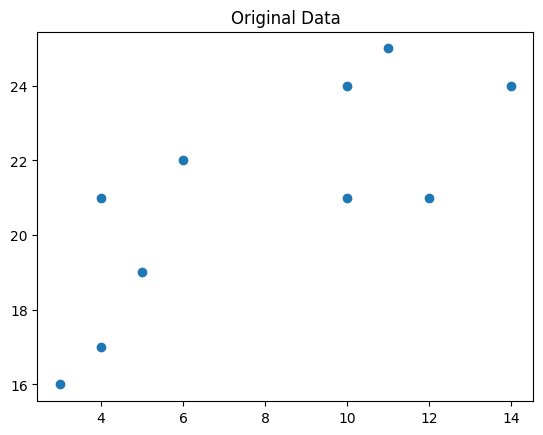

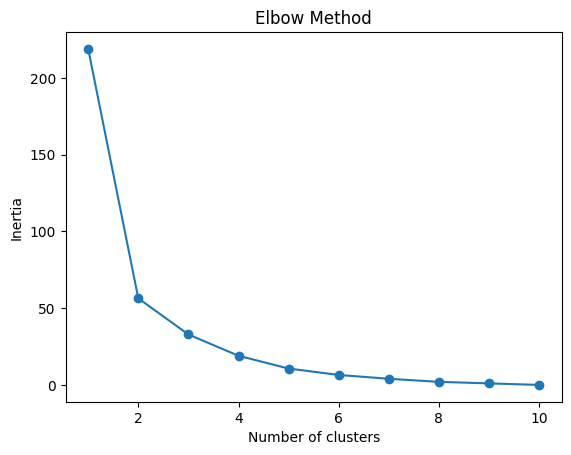

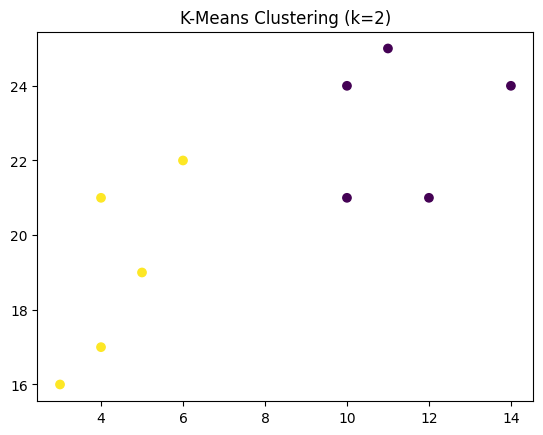

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Given data
x = [4, 5, 10, 4, 3, 11, 14, 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

# Scatter plot
plt.scatter(x, y)
plt.title("Original Data")
plt.show()

# Convert to dataset
data = list(zip(x, y))

# Elbow method
inertias = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# Apply KMeans with optimal k = 2
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(data)

# Plot clustered data
plt.scatter(x, y, c=kmeans.labels_, cmap='viridis')
plt.title("K-Means Clustering (k=2)")
plt.show()

10B – PCA + Logistic Regression

Explained Variance Ratio: [0.36884109 0.19318394]
Confusion Matrix:
 [[14  0  0]
 [ 1 15  0]
 [ 0  0  6]]


/tmp/ipykernel_119875/2666888854.py:69: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


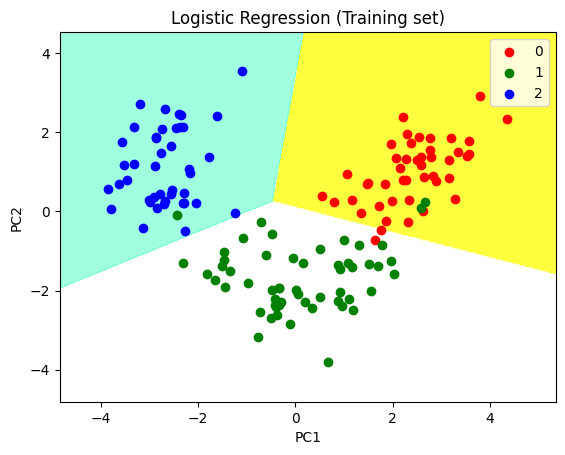

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset (no CSV needed)
from sklearn.datasets import load_wine
wine = load_wine()

# Convert to DataFrame
dataset = pd.DataFrame(wine.data, columns=wine.feature_names)
dataset['target'] = wine.target

# Split into X and y
X = dataset.iloc[:, 0:13].values
y = dataset.iloc[:, 13].values

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

# Feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

# Prediction
y_pred = classifier.predict(X_test)

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Visualization (Training set)
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('yellow', 'white', 'aquamarine'))
)

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(('red', 'green', 'blue'))(i),
        label=j
    )

plt.title('Logistic Regression (Training set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()